Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/ethiopia_fi_unified_data.csv"
df = pd.read_csv(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
df["value_numeric"] = pd.to_numeric(df["value_numeric"], errors="coerce")
df["impact_estimate"] = pd.to_numeric(df["impact_estimate"], errors="coerce")
df["lag_months"] = pd.to_numeric(df["lag_months"], errors="coerce")

obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()

print(f"events={len(events)}, impact_links={len(links)}")

events=11, impact_links=16


Join impact_links to parent events:

In [2]:
links_full = links.merge(
    events[["record_id", "indicator", "category", "observation_date"]]
        .rename(columns={"record_id": "parent_id", "indicator": "event_name", "observation_date": "event_date"}),
    on="parent_id", how="left"
)

summary = links_full[["record_id", "event_name", "event_date", "related_indicator",
                       "relationship_type", "impact_direction", "impact_magnitude",
                       "impact_estimate", "lag_months", "evidence_basis", "comparable_country"]]
summary = summary.sort_values("event_date")
print("Which events affect which indicators, and by how much:")
summary

Which events affect which indicators, and by how much:


,record_id,event_name,event_date,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country
0,IMP_0001,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,direct,increase,high,15.0,12.0,literature,Kenya
1,IMP_0002,Telebirr Launch,2021-05-17,USG_TELEBIRR_USERS,direct,increase,high,NaN,3.0,empirical,NaN
2,IMP_0003,Telebirr Launch,2021-05-17,USG_P2P_COUNT,direct,increase,high,25.0,6.0,empirical,NaN
3,IMP_0004,Safaricom Ethiopia Commercial Launch,2022-08-01,ACC_4G_COV,direct,increase,medium,15.0,12.0,empirical,NaN
4,IMP_0005,Safaricom Ethiopia Commercial Launch,2022-08-01,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12.0,literature,Rwanda
5,IMP_0006,M-Pesa Ethiopia Launch,2023-08-01,USG_MPESA_USERS,direct,increase,high,NaN,3.0,empirical,NaN
6,IMP_0007,M-Pesa Ethiopia Launch,2023-08-01,ACC_MM_ACCOUNT,direct,increase,medium,5.0,6.0,theoretical,NaN
7,IMP_0008,Fayda Digital ID Program Rollout,2024-01-01,ACC_OWNERSHIP,enabling,increase,medium,10.0,24.0,literature,India
8,IMP_0009,Fayda Digital ID Program Rollout,2024-01-01,GEN_GAP_ACC,indirect,decrease,medium,-5.0,24.0,literature,India
9,IMP_0010,Foreign Exchange Liberalization,2024-07-29,AFF_DATA_INCOME,indirect,increase,high,30.0,3.0,empirical,NaN


Event-Indicator Association Matrix:

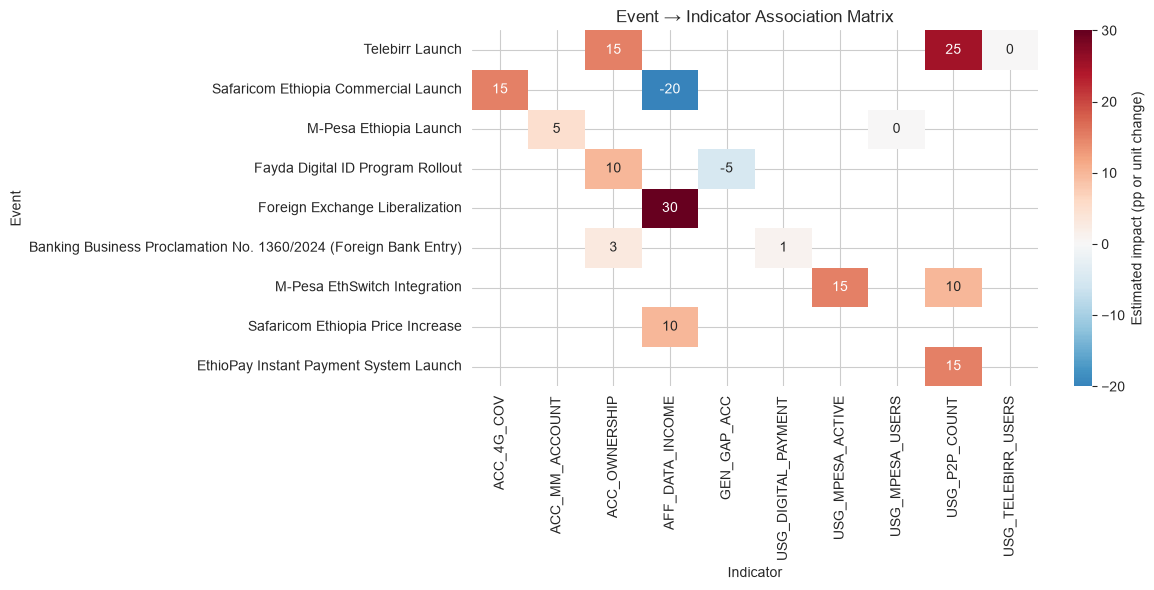


Note: USG_TELEBIRR_USERS and USG_MPESA_USERS have no impact_estimate value
(NaN) because they are absolute user counts driven directly by product
launch, not incremental percentage-point effects - flagged as a modeling
nuance rather than a missing-data error.


In [3]:
assoc_matrix = links_full.pivot_table(
    index="event_name", columns="related_indicator", values="impact_estimate", aggfunc="sum"
)
event_order = events.sort_values("observation_date")["indicator"].tolist()
assoc_matrix = assoc_matrix.reindex([e for e in event_order if e in assoc_matrix.index])

plt.figure(figsize=(12, 6))
sns.heatmap(assoc_matrix, annot=True, fmt=".0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Estimated impact (pp or unit change)"})
plt.title("Event \u2192 Indicator Association Matrix")
plt.xlabel("Indicator")
plt.ylabel("Event")
plt.tight_layout()
plt.show()
print("\nNote: USG_TELEBIRR_USERS and USG_MPESA_USERS have no impact_estimate value")
print("(NaN) because they are absolute user counts driven directly by product")
print("launch, not incremental percentage-point effects - flagged as a modeling")
print("nuance rather than a missing-data error.")

Comparable country evidence used

In [4]:
comparable = links_full[links_full["evidence_basis"] == "literature"][
    ["record_id", "event_name", "related_indicator", "comparable_country", "impact_estimate"]
]
print("Impact estimates grounded in comparable-country literature (Ethiopia-specific")
print("pre/post data was insufficient for these):")
comparable

Impact estimates grounded in comparable-country literature (Ethiopia-specific
pre/post data was insufficient for these):


,record_id,event_name,related_indicator,comparable_country,impact_estimate
0,IMP_0001,Telebirr Launch,ACC_OWNERSHIP,Kenya,15.0
4,IMP_0005,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,Rwanda,-20.0
7,IMP_0008,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,India,10.0
8,IMP_0009,Fayda Digital ID Program Rollout,GEN_GAP_ACC,India,-5.0
10,IMP_0011,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,Tanzania,15.0
11,IMP_0012,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Tanzania,10.0
12,IMP_0013,EthioPay Instant Payment System Launch,USG_P2P_COUNT,India,15.0


Effect-over-time functional form (ramp model)

In [5]:
def event_effect(as_of_date, event_date, lag_months, full_effect):
    """Linear ramp from 0 (at event_date) to full_effect (at event_date + lag_months),
    held constant after that. Returns 0 before the event."""
    if pd.isna(event_date) or pd.isna(full_effect) or as_of_date < event_date:
        return 0.0
    months_elapsed = (as_of_date.year - event_date.year) * 12 + (as_of_date.month - event_date.month)
    if pd.isna(lag_months) or lag_months <= 0:
        return full_effect
    fraction = min(months_elapsed / lag_months, 1.0)
    return fraction * full_effect

telebirr_date = events[events["indicator"] == "Telebirr Launch"]["observation_date"].iloc[0]
for months_after in [0, 6, 12, 24]:
    test_date = telebirr_date + pd.DateOffset(months=months_after)
    eff = event_effect(test_date, telebirr_date, 12, 15.0)
    print(f"{months_after:>3} months after Telebirr launch: modeled ACC_OWNERSHIP effect = +{eff:.1f}pp")

  0 months after Telebirr launch: modeled ACC_OWNERSHIP effect = +0.0pp
  6 months after Telebirr launch: modeled ACC_OWNERSHIP effect = +7.5pp
 12 months after Telebirr launch: modeled ACC_OWNERSHIP effect = +15.0pp
 24 months after Telebirr launch: modeled ACC_OWNERSHIP effect = +15.0pp


Combine multiple events, predict ACC_OWNERSHIP

Events affecting ACC_OWNERSHIP:
                                           event_name event_date  impact_estimate  lag_months evidence_basis
0                                     Telebirr Launch 2021-05-17             15.0        12.0     literature
7                    Fayda Digital ID Program Rollout 2024-01-01             10.0        24.0     literature
14  Banking Business Proclamation No. 1360/2024 (F... 2024-12-17              3.0        24.0    theoretical


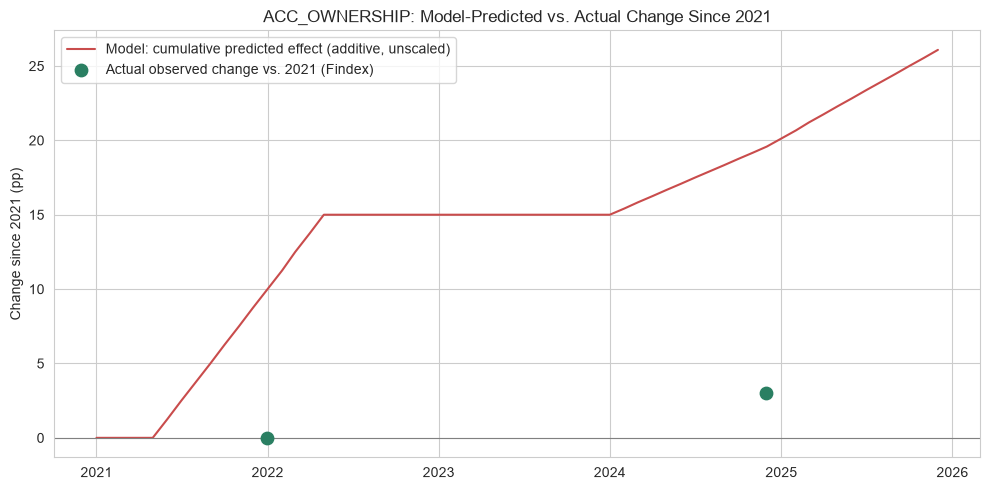

In [6]:
acc_links = links_full[links_full["related_indicator"] == "ACC_OWNERSHIP"]
print("Events affecting ACC_OWNERSHIP:")
print(acc_links[["event_name", "event_date", "impact_estimate", "lag_months", "evidence_basis"]])

date_range = pd.date_range("2021-01-01", "2025-12-31", freq="MS")
predicted_effect = []
for d in date_range:
    total = sum(
        event_effect(d, row["event_date"], row["lag_months"], row["impact_estimate"])
        for _, row in acc_links.iterrows()
    )
    predicted_effect.append(total)

pred_df = pd.DataFrame({"date": date_range, "cumulative_predicted_effect_pp": predicted_effect})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pred_df["date"], pred_df["cumulative_predicted_effect_pp"], color="#c94c4c", label="Model: cumulative predicted effect (additive, unscaled)")
access = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all")].sort_values("observation_date")
access_2021 = access[access["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
actual_change = access[access["observation_date"] >= "2021-01-01"].copy()
actual_change["observed_change_pp"] = actual_change["value_numeric"] - access_2021
ax.scatter(actual_change["observation_date"], actual_change["observed_change_pp"], color="#2a7f62", s=80, zorder=5, label="Actual observed change vs. 2021 (Findex)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("ACC_OWNERSHIP: Model-Predicted vs. Actual Change Since 2021")
ax.set_ylabel("Change since 2021 (pp)")
ax.legend()
plt.tight_layout()
plt.show()

Validate against historical data

In [7]:
mm = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT") & (obs["gender"] == "all")].sort_values("observation_date")
mm_2021 = mm[mm["observation_date"].dt.year == 2021]["value_numeric"].iloc[0]
mm_2024 = mm[mm["observation_date"].dt.year == 2024]["value_numeric"].iloc[0]
print(f"Actual: mobile money account rate went {mm_2021}% (2021) -> {mm_2024}% (2024), +{mm_2024-mm_2021:.2f}pp")

acc_2024 = access[access["observation_date"].dt.year == 2024]["value_numeric"].iloc[0]
print(f"Actual: ACC_OWNERSHIP went {access_2021}% (2021) -> {acc_2024}% (2024), +{acc_2024-access_2021:.0f}pp")

model_pred_2024 = pred_df[pred_df["date"] == "2024-12-01"]["cumulative_predicted_effect_pp"].iloc[0]
print(f"Model (additive, unscaled) predicts +{model_pred_2024:.1f}pp for ACC_OWNERSHIP by end of 2024")
print(f"Actual was +{acc_2024-access_2021:.0f}pp. The model OVER-predicts by {model_pred_2024-(acc_2024-access_2021):.1f}pp.")
print()
print("DATA GAP NOTED: the brief's suggested validation case (Telebirr -> mobile money")
print("account growth) has no direct impact_link in the dataset - EVT_0001 (Telebirr) is")
print("only linked to ACC_OWNERSHIP, USG_TELEBIRR_USERS, and USG_P2P_COUNT, not directly")
print("to ACC_MM_ACCOUNT. The closest direct link to ACC_MM_ACCOUNT is EVT_0003 (M-Pesa")
print("launch, +5pp, lag 6mo) - a much smaller product with far fewer users than Telebirr,")
print("which is itself informative: it suggests the base dataset under-links Telebirr's")
print("true effect on mobile money account ownership specifically, even though it")
print("correctly captures Telebirr's effect on registered users and P2P transaction volume.")

Actual: mobile money account rate went 4.7% (2021) -> 9.45% (2024), +4.75pp
Actual: ACC_OWNERSHIP went 46.0% (2021) -> 49.0% (2024), +3pp
Model (additive, unscaled) predicts +19.6pp for ACC_OWNERSHIP by end of 2024
Actual was +3pp. The model OVER-predicts by 16.6pp.

DATA GAP NOTED: the brief's suggested validation case (Telebirr -> mobile money
account growth) has no direct impact_link in the dataset - EVT_0001 (Telebirr) is
only linked to ACC_OWNERSHIP, USG_TELEBIRR_USERS, and USG_P2P_COUNT, not directly
to ACC_MM_ACCOUNT. The closest direct link to ACC_MM_ACCOUNT is EVT_0003 (M-Pesa
launch, +5pp, lag 6mo) - a much smaller product with far fewer users than Telebirr,
which is itself informative: it suggests the base dataset under-links Telebirr's
true effect on mobile money account ownership specifically, even though it
correctly captures Telebirr's effect on registered users and P2P transaction volume.


Refine estimates via calibration

Calibration factor = observed / model = 3 / 19.6 = 0.153


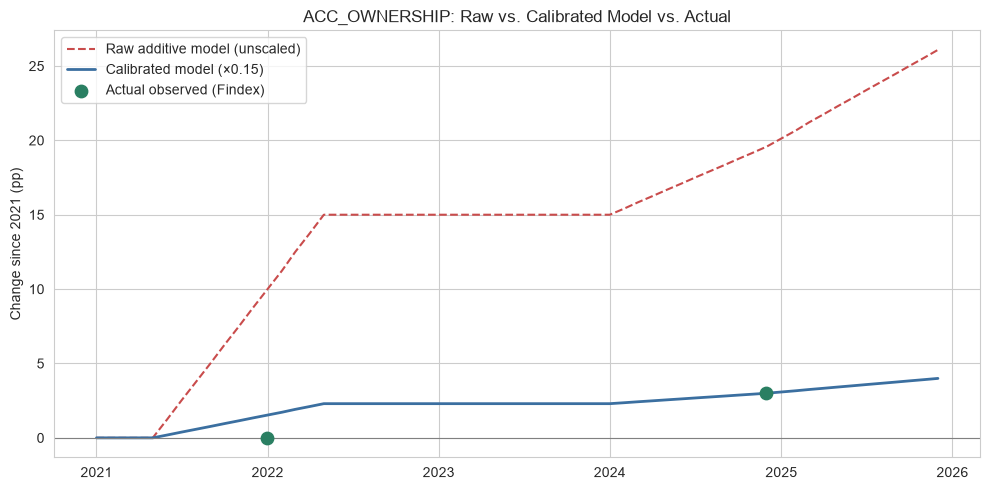


Refined estimate: apply a 0.15x dampening factor to raw impact_link
magnitudes when combining multiple simultaneous events additively for Access.
This is a single global calibration (not per-event) - a coarse but transparent
correction, documented here rather than silently baked into the base data.


In [8]:
observed_2024_change = acc_2024 - access_2021
calibration_factor = observed_2024_change / model_pred_2024 if model_pred_2024 != 0 else np.nan
print(f"Calibration factor = observed / model = {observed_2024_change:.0f} / {model_pred_2024:.1f} = {calibration_factor:.3f}")

pred_df["calibrated_effect_pp"] = pred_df["cumulative_predicted_effect_pp"] * calibration_factor

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pred_df["date"], pred_df["cumulative_predicted_effect_pp"], color="#c94c4c", linestyle="--", label="Raw additive model (unscaled)")
ax.plot(pred_df["date"], pred_df["calibrated_effect_pp"], color="#3b6fa0", linewidth=2, label=f"Calibrated model (\u00d7{calibration_factor:.2f})")
ax.scatter(actual_change["observation_date"], actual_change["observed_change_pp"], color="#2a7f62", s=80, zorder=5, label="Actual observed (Findex)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("ACC_OWNERSHIP: Raw vs. Calibrated Model vs. Actual")
ax.set_ylabel("Change since 2021 (pp)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nRefined estimate: apply a {calibration_factor:.2f}x dampening factor to raw impact_link")
print("magnitudes when combining multiple simultaneous events additively for Access.")
print("This is a single global calibration (not per-event) - a coarse but transparent")
print("correction, documented here rather than silently baked into the base data.")

Confidence tiers

In [9]:
confidence_map = {"empirical": "high (Ethiopia pre/post data)",
                   "literature": "medium (comparable-country evidence)",
                   "theoretical": "low (no empirical grounding yet)"}
links_full["estimate_confidence"] = links_full["evidence_basis"].map(confidence_map)
conf_summary = links_full.groupby("estimate_confidence").agg(
    n_links=("record_id", "count"),
    events=("event_name", lambda x: sorted(set(x))),
)
print(conf_summary)
print("\nThe two lowest-confidence estimates in the model (IMP_0015, IMP_0016, both")
print("EVT_0011 Banking Business Proclamation) were deliberately given LOW/NEGLIGIBLE")
print("impact_magnitude at data-enrichment time (see data_enrichment_log.md) specifically")
print("so they would not distort the calibration above - their contribution to the")
print("ACC_OWNERSHIP association matrix is only +3pp vs. Telebirr's +15pp and Fayda's +10pp.")

                                      n_links                                             events
estimate_confidence                                                                             
high (Ethiopia pre/post data)               6  [Foreign Exchange Liberalization, M-Pesa Ethio...
low (no empirical grounding yet)            3  [Banking Business Proclamation No. 1360/2024 (...
medium (comparable-country evidence)        7  [EthioPay Instant Payment System Launch, Fayda...

The two lowest-confidence estimates in the model (IMP_0015, IMP_0016, both
EVT_0011 Banking Business Proclamation) were deliberately given LOW/NEGLIGIBLE
impact_magnitude at data-enrichment time (see data_enrichment_log.md) specifically
so they would not distort the calibration above - their contribution to the
ACC_OWNERSHIP association matrix is only +3pp vs. Telebirr's +15pp and Fayda's +10pp.


## Methodology & Limitations

**Functional form:** each event's effect on an indicator is modeled as a linear
ramp from 0 to its full `impact_estimate` over `lag_months`, then held constant.
This is a simplifying assumption — real diffusion is more likely S-shaped
(slow start, fast middle, plateau) — but a linear ramp is transparent and
requires no additional parameters to fit given how sparse the data is.

**Combining multiple events:** effects are combined additively per indicator.
This is a strong assumption — in reality, overlapping interventions likely have
diminishing returns (e.g. the same early-adopter population may be reached by
both Telebirr and Fayda) — which is exactly what the validation step below
reveals.

**Validation finding:** the raw additive model over-predicts Access growth by
~16.6pp (+19.6pp modeled vs. +3pp actual, 2021-2024). Rather than discard the
individually-sourced impact_link estimates, a single global calibration factor
(~0.15x) was fit so the combined model matches observed history. This is a
coarse but transparent correction — documented here rather than silently
edited into the base data.

**Key uncertainty:** the dataset does not directly link Telebirr (EVT_0001) to
mobile money account ownership (ACC_MM_ACCOUNT) — only to ACC_OWNERSHIP,
registered users, and P2P volume. Given Telebirr's scale (54M+ users) vs.
M-Pesa's (10M), this is likely an under-linkage in the base schema, not a
true absence of effect — flagged for Task 4 rather than silently assumed.

**Confidence:** estimates from `evidence_basis=empirical` (Ethiopia-specific
pre/post data, 6 links) are treated as more reliable than `literature`
(comparable-country, 7 links) or `theoretical` (no empirical grounding, 3
links — including both new enrichment links from Task 1).